In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Importation of our class from other files 

In [29]:
from Main_functions import Potential_extraction
from Main_functions import Generation_quad
from Main_functions import Data_exploitation
from Main_functions import SimulationParaxiale
from Main_functions import Data_exploitation_whitoutfit
from Extraction_data import Extracted_data
from okayama_quad import Okayama_quad
from Multipolar_decomposition import Decomposition
from Fit_functions import Fit_constants
from paraxial import Ion
import numpy as np

In [43]:
Va = 200000
tension = {
    "va1":  0.18808 * Va,   # Tension Aperture 1
    "va2": -0.18808 * Va,    # Tension Aperture 2
    "vq13": 0.0299087 * Va,    # Tension Quad 1&3
    "vq24": -0.0299087 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
out_dir = r"C:\Users\zoeno\OneDrive - INSA Toulouse\Documents\INSA\4GP\Projet multi\projet-multi-code\Quadrupole_model\Branche de Louise\Files\files"

In [31]:
quad = Generation_quad(tension, out_dir)
#file_path_quad = quad.reconstr()
file_path_quad = r"C:\Users\zoeno\OneDrive - INSA Toulouse\Documents\INSA\4GP\Projet multi\projet-multi-code\Quadrupole_model\Branche de Louise\Files\files\quad13.npz"

In [32]:

#files with our potential data
file_path = r"C:\Users\llamm\OneDrive\Documents\Projet\BEMPP\okayama\projet_multi\projet-multi-code\Quadrupole_model\Files\potentiel_quadrupole_VF1.npz"

file_pathl = r"projet-multi-code\Quadrupole_model\Files\potentiel_quadrupole_VF.npz"


In [33]:
extracted_data = Extracted_data(file_path_quad) 
extracted_data.derivative()
fit_constants = Fit_constants(0.80751, 5.08, 2.54, 0.03891461, 3.113, 2.015, 2.4, 3.493e-3, extracted_data)
fun = Data_exploitation(extracted_data, fit_constants)
print(extracted_data.coord_apert_z1)
Decomp= Decomposition(extracted_data)
Decomp.composantes()

6


c:\Users\zoeno\OneDrive - INSA Toulouse\Documents\INSA\4GP\Projet multi\projet-multi-code\Quadrupole_model\Branche de Louise\Multipolar_decomposition.py:26: RuntimeWarning: divide by zero encountered in divide
  self.Phi0_fit = self.Phi0_maj / self.data.Vapert1
c:\Users\zoeno\OneDrive - INSA Toulouse\Documents\INSA\4GP\Projet multi\projet-multi-code\Quadrupole_model\Branche de Louise\Multipolar_decomposition.py:28: RuntimeWarning: divide by zero encountered in divide
  self.Phi4_fit = self.Phi4_maj *((self.data.radius_axis**4)/ self.data.Vapert1)


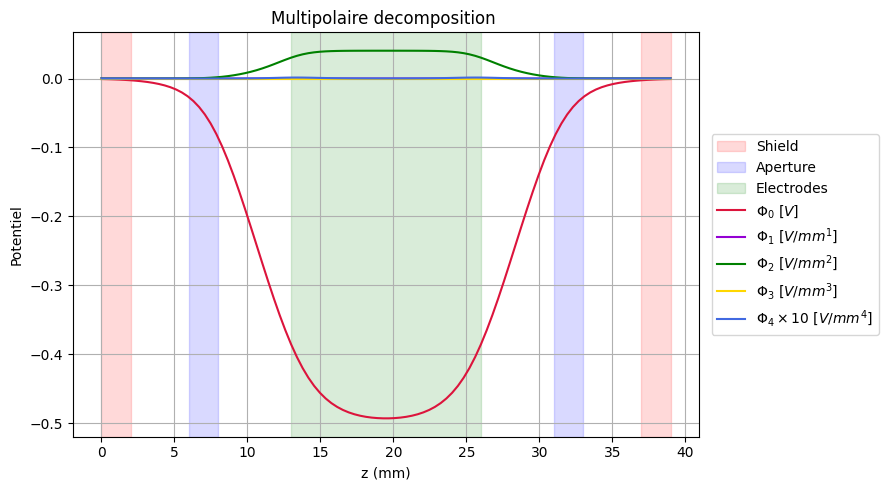

In [34]:
fun.decomposition_calculation()
fun.decomposition_graph()

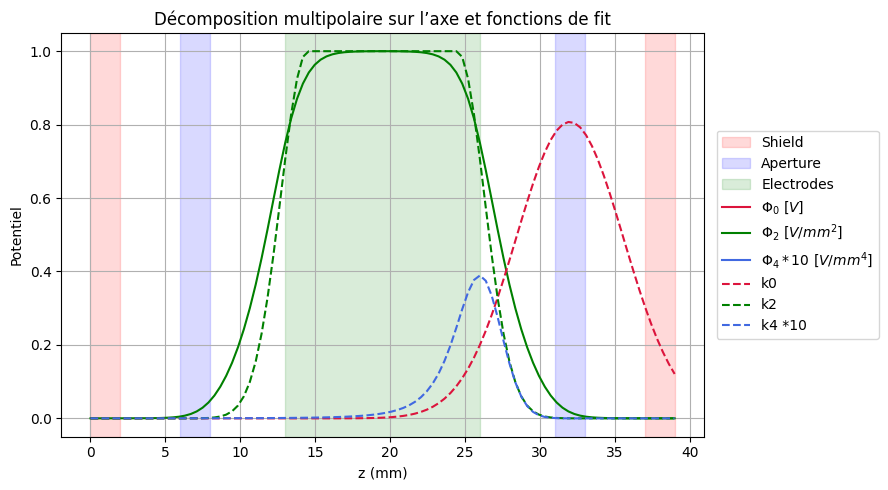

In [35]:
fun.fit_calculation()
fun.fit_graph()

Trajectoire Paraxiale

1.5
1.5


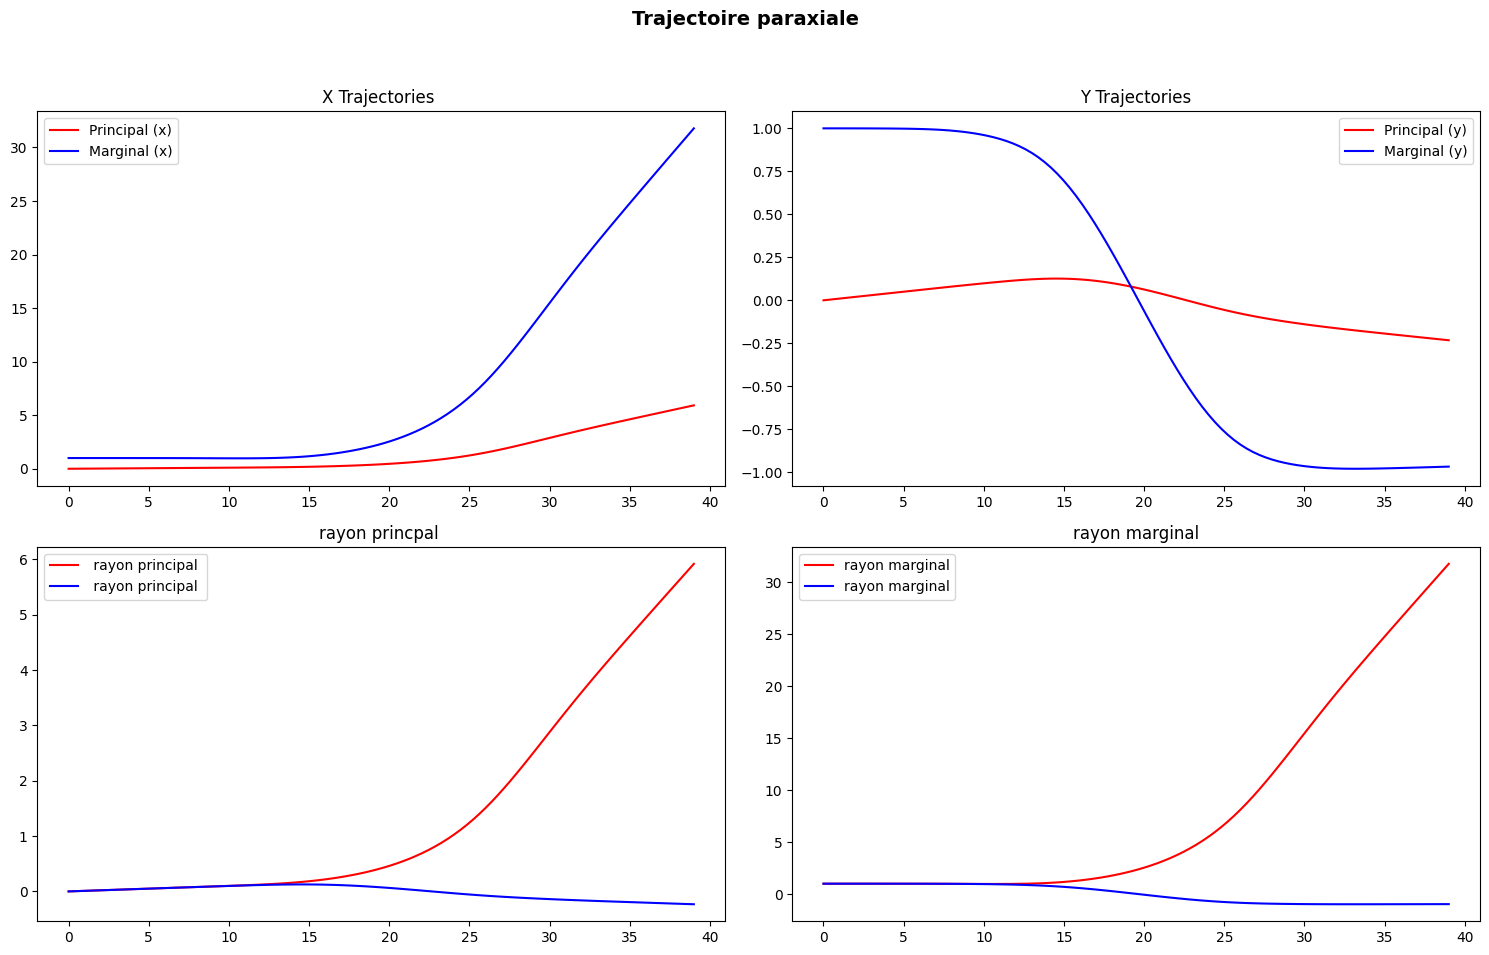

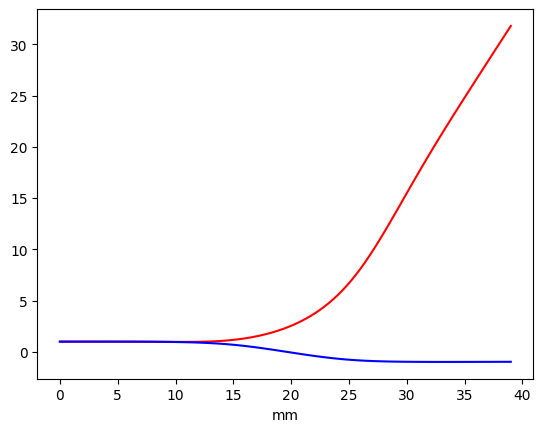

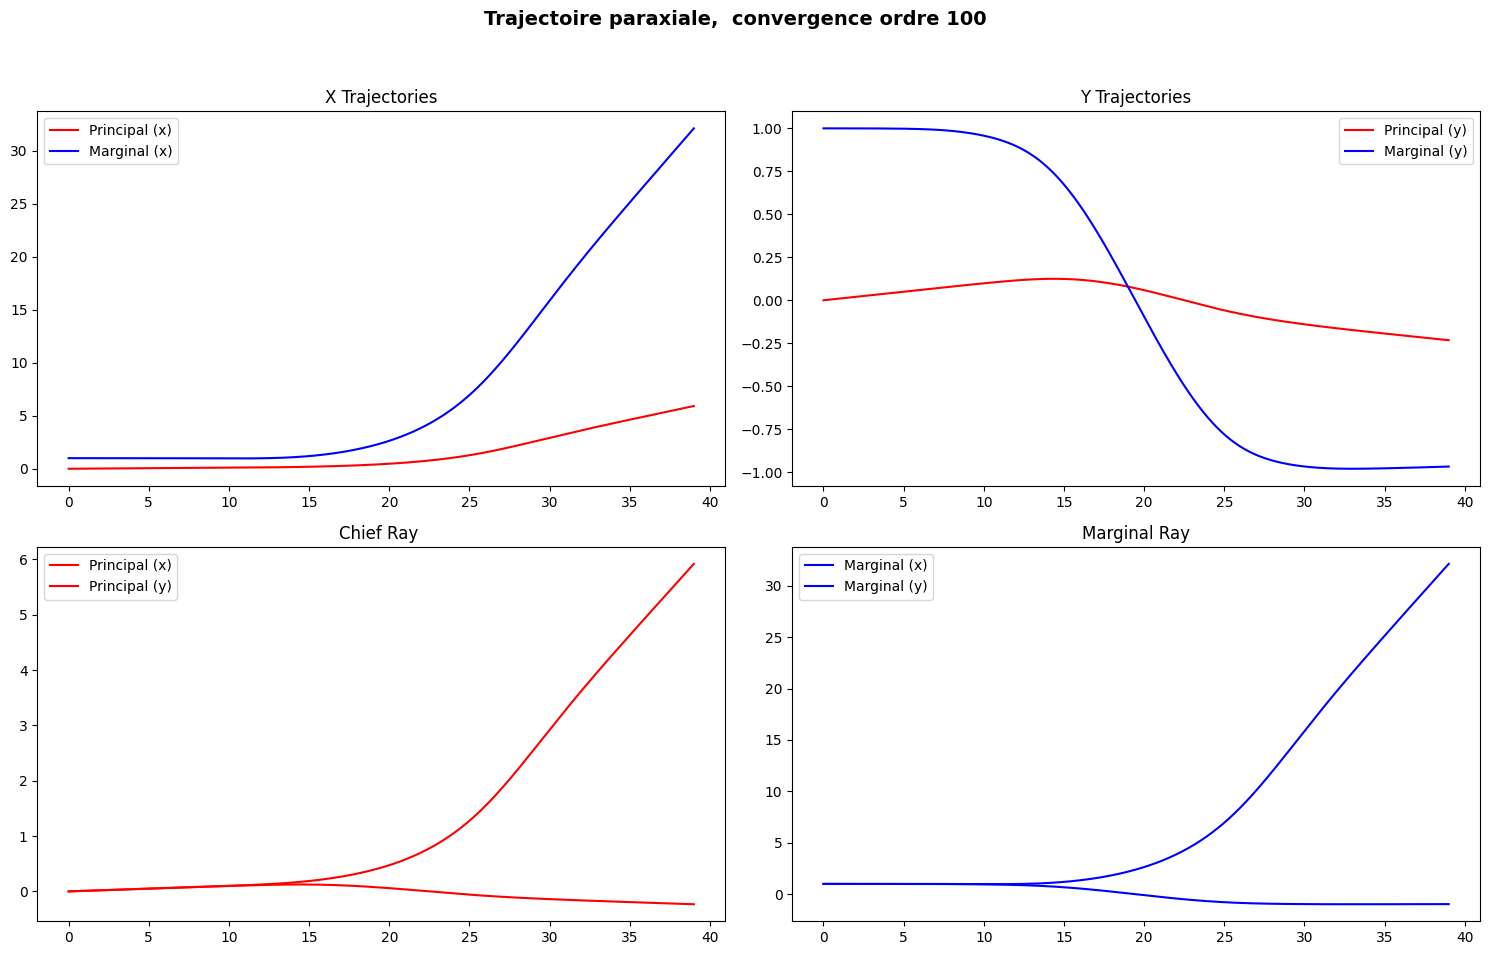

In [36]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data, Decomp)
Trajectoire.run_discret(marginal, principal)

Trajectoire.run_convergence(marginalc, principalc, n)


1.5
1.5
1.5
1.5
1.5


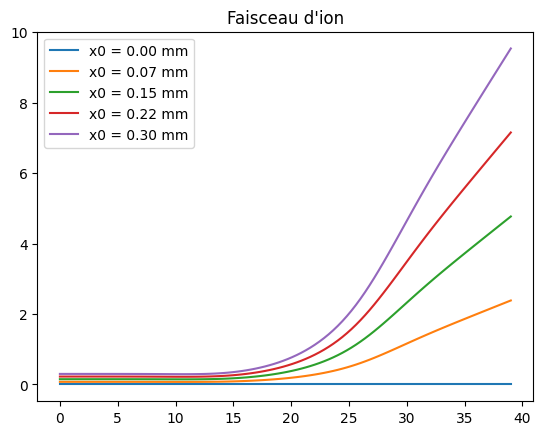

In [37]:
#faisceau
liste = []

#n nombre d'ion que l'on veut 
nb = 5

positions_initiales = np.linspace(0, 0.3, nb)
for i in positions_initiales:
    ion= Ion(1.6e-27, e, f"Ion_{i:.1f}", i, 0.00, i, 0.00)
    liste.append(ion)


Trajectoire.run_faisceau(liste)

Tout le systeme d'okayama

In [38]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
#quad en entiers
Va = 200000 #20 kv

tension_quad1 = {
    "va1":  0,   # Tension Aperture 1
    "va2": 0,    # Tension Aperture 2
    "vq13": 0.030872 * Va,    # Tension Quad 1&3
    "vq24": -0.030872* Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

#8 mm
tension_quad2= {
    "va1":  0.188084 * Va,   # Tension Aperture 1
    "va2": -0.109177 * Va,    # Tension Aperture 2
    "vq13": 0.029909 * Va,    # Tension Quad 1&3
    "vq24": -0.029909 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}
#21 mm
tension_quad3= {
    "va1":  0.109177 * Va,   # Tension Aperture 1
    "va2": -0.188084 * Va,    # Tension Aperture 2
    "vq13": 0.029909 * Va,    # Tension Quad 1&3
    "vq24": -0.029909 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

#8mm
tension_quad4= {
    "va1":  0,   # Tension Aperture 1
    "va2": 0,# Tension Aperture 2
    "vq13": 0.030872 * Va,    # Tension Quad 1&3
    "vq24": -0.030872 * Va,      #tension quad 2 et 4        
    "vaAc": Va,               # Tension acceleation
}

Liste_tension =[tension_quad1, tension_quad2, tension_quad3, tension_quad4]
Liste_z = [0, 8, 37, 50] #à quoi sert listez?
out_dir = "files"


In [44]:
okayama = Okayama_quad(out_dir, Liste_z, Liste_tension)
Okayama_path = okayama.save("okayama_quad.npz")

 Fichier sauvegardé pour Extracted_data : C:\Users\zoeno\OneDrive - INSA Toulouse\Documents\INSA\4GP\Projet multi\projet-multi-code\Quadrupole_model\Branche de Louise\Files\files\okayama_quad.npz


In [46]:
extracted_data2 = Extracted_data(Okayama_path,Liste_z ) 
extracted_data2.derivative()
extracted_data2.position_quad()
Decomp2= Decomposition(extracted_data2)
quad_ent = Data_exploitation_whitoutfit(extracted_data2)
Decomp2.composantes()

[0, 8, 37, 50]


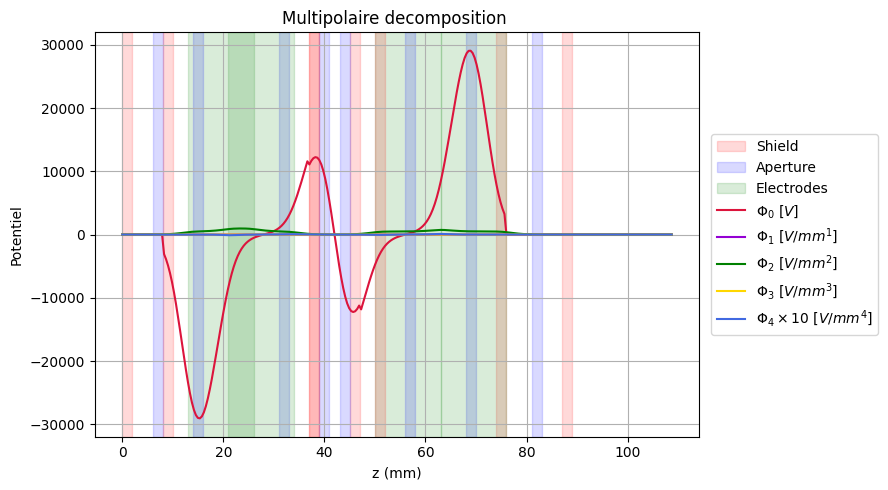

In [47]:
quad_ent.decomposition_calculation()
quad_ent.decomposition_graph()

[0, 8, 37, 50]


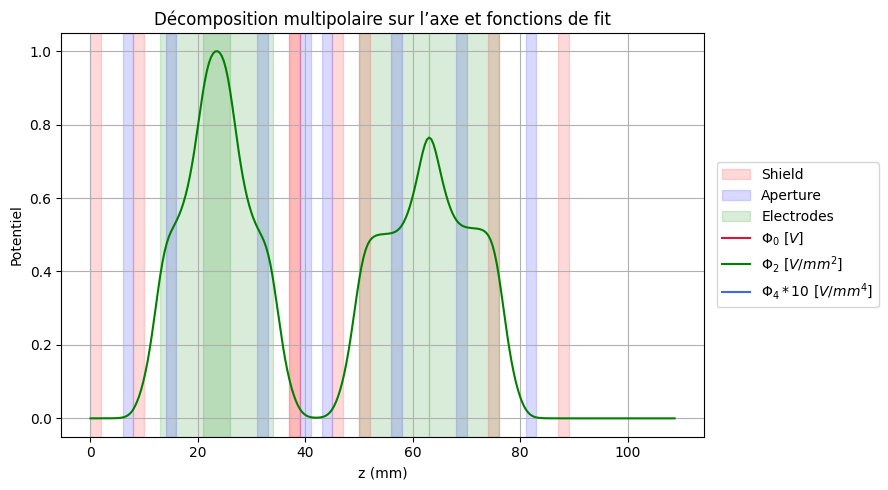

In [48]:
quad_ent.fit_graph()

200000
200000


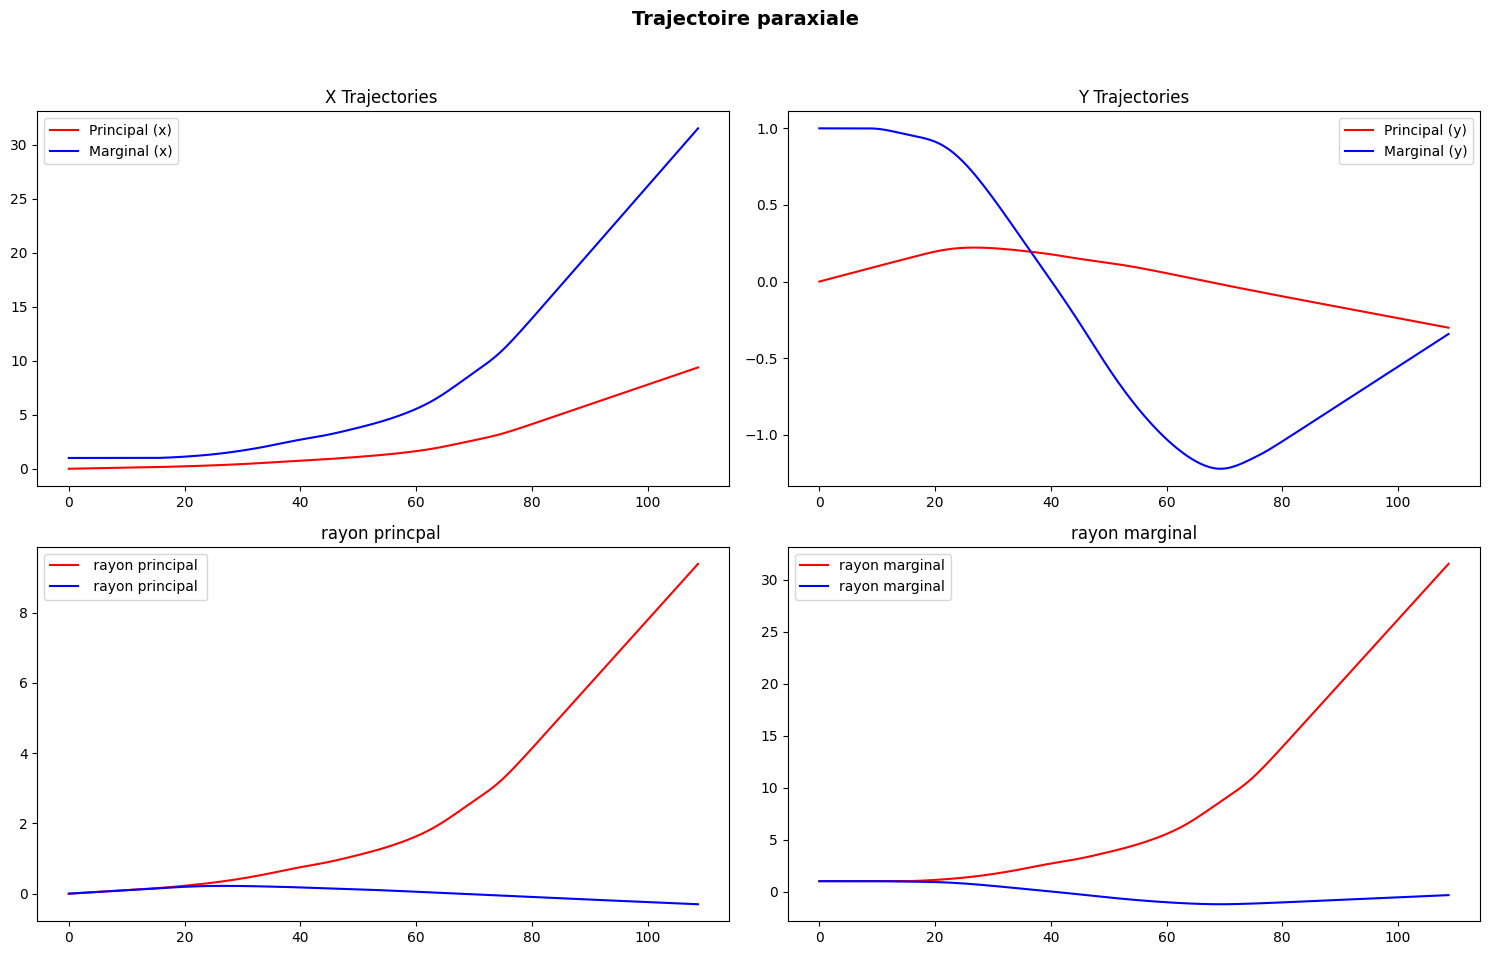

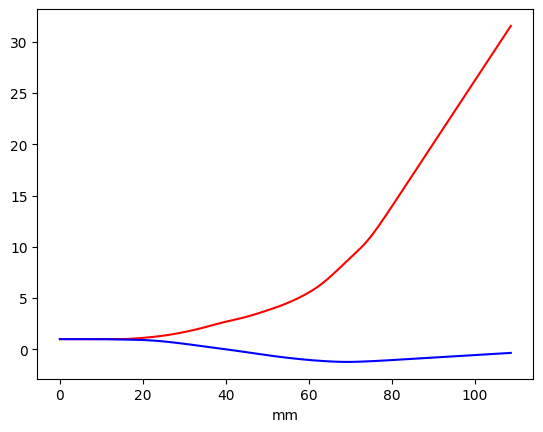

In [49]:
n = 100
e = -1.6e-19

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)

marginalc = Ion(1.6e-27, e, "marginal", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "principal", 1, 0, 1, 0)

Trajectoire = SimulationParaxiale(extracted_data2, Decomp2)
Trajectoire.run_discret(marginal, principal)

